# Lab 15: Thực hành với phương pháp Transfer Learning + Fine-tune

## 1) Chuẩn bị môi trường

In [1]:
!nvidia-smi -L || true  # kiểm tra GPU (tuỳ chọn)

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import os, random, numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(tf.__version__)


2.20.0


## 2) Tạo tập 300 ảnh CIFAR-10 cân bằng (30 ảnh/lớp)

In [3]:
from tensorflow.keras.datasets import cifar10
# Tải CIFAR-10
(x_train_full, y_train_full), _ = cifar10.load_data()
y_train_full = y_train_full.reshape(-1)

# Tên lớp CIFAR-10
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
num_classes = len(CLASS_NAMES)

# Lấy 30 ảnh/lớp
per_class = 30
idx_keep = []
rng = np.random.RandomState(SEED)
for cls in range(num_classes):
    idx_cls = np.where(y_train_full == cls)[0]
    chosen = rng.choice(idx_cls, size=per_class, replace=False)
    idx_keep.extend(chosen)
idx_keep = np.array(idx_keep)

X = x_train_full[idx_keep]
y = y_train_full[idx_keep]

print("Dataset shape:", X.shape, y.shape)
# Split 80/20 giữ cân bằng lớp
X_train, X_val, y_train_int, y_val_int = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# One-hot cho training (để dùng label smoothing)
y_train = tf.keras.utils.to_categorical(y_train_int, num_classes)
y_val   = tf.keras.utils.to_categorical(y_val_int,   num_classes)

print("Train:", X_train.shape, "Val:", X_val.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2373s 14us/step
Dataset shape: (300, 32, 32, 3) (300,)
Train: (240, 32, 32, 3) Val: (60, 32, 32, 3)


## 3) Tạo tf.data.Dataset + Augmentation

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
])

def preprocess(x, y):
    x = tf.image.resize(tf.cast(x, tf.float32), IMG_SIZE) / 255.0
    return x, y

def make_ds(images, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
        ds = ds.map(lambda x,y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val,   training=False)


## 4) Xây mô hình MobileNetV2 (pretrained) + head mới

In [5]:
from tensorflow.keras import layers, models, regularizers

base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base.trainable = False  # Phase 1: đóng băng backbone

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = inputs
# (Rescale đã làm ở pipeline preprocess)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax",
                       kernel_regularizer=regularizers.l2(1e-4))(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5) Huấn luyện Pha 1 (warm-up head)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
]

history1 = model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, verbose=1)


Epoch 1/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 844ms/step - accuracy: 0.1292 - loss: 2.7839 - val_accuracy: 0.2500 - val_loss: 2.5496
Epoch 2/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - accuracy: 0.1625 - loss: 2.5545 - val_accuracy: 0.3500 - val_loss: 2.2853
Epoch 3/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.1917 - loss: 2.3868 - val_accuracy: 0.4000 - val_loss: 2.1265
Epoch 4/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.2917 - loss: 2.2643 - val_accuracy: 0.4000 - val_loss: 2.0626
Epoch 5/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.3167 - loss: 2.1152 - val_accuracy: 0.3833 - val_loss: 1.9378
Epoch 6/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 457ms/step - accuracy: 0.3375 - loss: 2.0769 - val_accuracy: 0.4667 - val_loss: 1.8423
Epoch 7/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.3250 - loss: 1.9556 - val_accuracy: 0.4500 - val_loss: 1.8543
Epoch 8/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.3708 - loss: 1.8925 - val_accuracy: 0.4167 - val_loss

## 6) Fine-tune Pha 2 (mở khóa các lớp cuối)

In [7]:
# Mở khóa ~40 lớp cuối
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks_ft = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2, verbose=1, monitor='val_loss'),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
]

history2 = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks_ft, verbose=1)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2375 - loss: 2.3562 - val_accuracy: 0.6000 - val_loss: 1.5540 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 637ms/step - accuracy: 0.4042 - loss: 1.8431 - val_accuracy: 0.5500 - val_loss: 1.5305 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 612ms/step - accuracy: 0.4917 - loss: 1.6358 - val_accuracy: 0.5333 - val_loss: 1.5944 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5793 - loss: 1.4183
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 759ms/step - accuracy: 0.5833 - loss: 1.4254 - val_accuracy: 0.5667 - val_loss: 1.6884 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 709ms/step - accuracy: 0.6458 - loss: 1.3912 - val_accuracy: 0.5500 - val_loss: 1.7128 - learning_rate: 2.0000e-05
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.6639 - loss: 1.30

## 7) Vẽ learning curves (acc & loss)

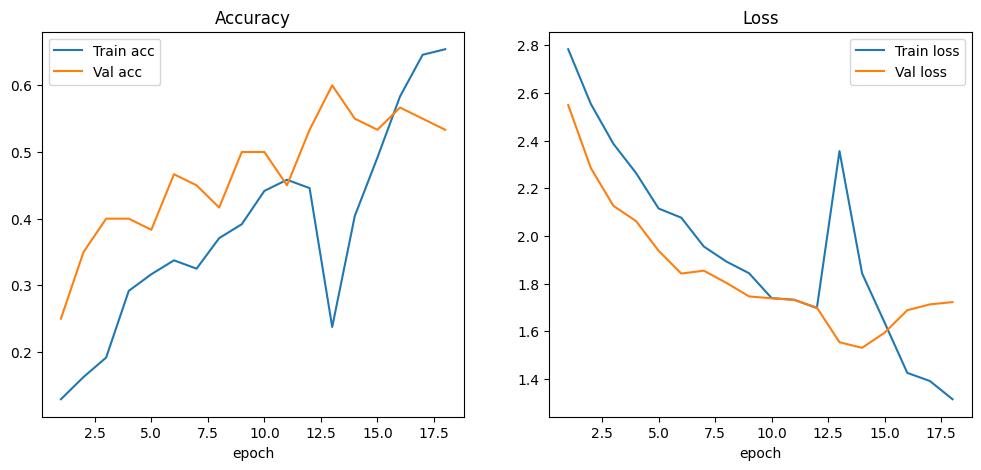

In [8]:
def plot_histories(h1, h2):
    hist = {}
    for k in ['accuracy','val_accuracy','loss','val_loss']:
        hist[k] = h1.history.get(k, []) + h2.history.get(k, [])
    epochs = range(1, len(hist['accuracy'])+1)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist['accuracy'], label='Train acc')
    plt.plot(epochs, hist['val_accuracy'], label='Val acc')
    plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, hist['loss'], label='Train loss')
    plt.plot(epochs, hist['val_loss'], label='Val loss')
    plt.title('Loss'); plt.xlabel('epoch'); plt.legend()
    plt.show()

plot_histories(history1, history2)


## 8) Đánh giá & Confusion Matrix

Validation accuracy (recomputed): 0.6


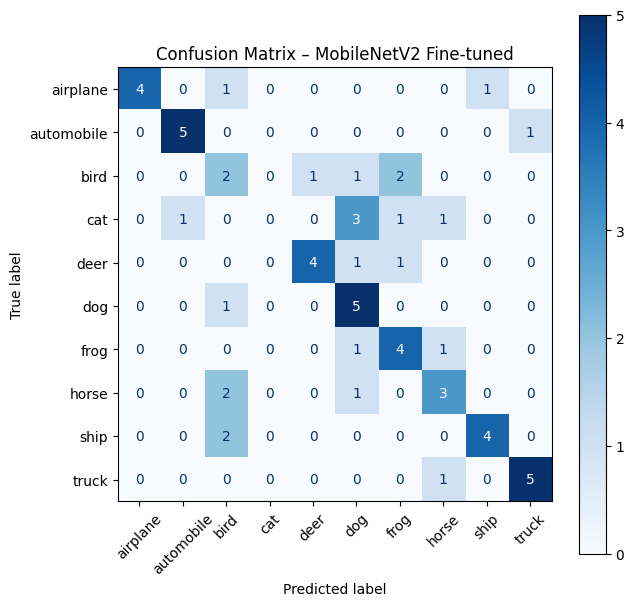

In [9]:
# Dự đoán trên tập val
# (cần nhãn int để vẽ confusion matrix)
y_pred = []
for batch, _ in tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE):
    batch = tf.image.resize(tf.cast(batch, tf.float32), IMG_SIZE) / 255.0
    p = model.predict(batch, verbose=0)
    y_pred.extend(np.argmax(p, axis=1))
y_pred = np.array(y_pred)

print("Validation accuracy (recomputed):", (y_pred == y_val_int).mean())

# Vẽ confusion matrix
cm = confusion_matrix(y_val_int, y_pred, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix – MobileNetV2 Fine-tuned")
plt.show()


## 9) Test-Time Augmentation (TTA) để “vắt” thêm vài % acc

In [17]:
def tta_predict(images, tta_times=5):
    probs = []
    # Define a helper function to apply augmentation to a single image (rank 3 tensor)
    # This aligns with how data_augmentation was first traced/built in make_ds.
    def augment_single_img_helper(img):
        return data_augmentation(img, training=True)

    for _ in range(tta_times):
        # Apply the single-image augmentation helper to each image in the batch using tf.map_fn
        # images has shape (BATCH_SIZE, H, W, C)
        # tf.map_fn will call augment_single_img_helper with each (H, W, C) image
        # The output aug_imgs_original_size will be (BATCH_SIZE, H, W, C)
        aug_imgs_original_size = tf.map_fn(
            augment_single_img_helper,
            images,
            fn_output_signature=tf.TensorSpec(shape=(32, 32, 3), dtype=tf.float32) # Augmentation layers output float32
        )

        # Then preprocess the entire augmented batch (cast to float32, resize, and normalize)
        processed_aug_imgs = tf.image.resize(tf.cast(aug_imgs_original_size, tf.float32), IMG_SIZE) / 255.0
        p = model.predict(processed_aug_imgs, verbose=0)
        probs.append(p)
    return np.mean(probs, axis=0)

# tính acc TTA trên val
tta_preds = []
for batch, _ in tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE):
    # 'batch' here contains the images part, with shape (BATCH_SIZE, 32, 32, 3)
    p = tta_predict(batch, tta_times=5)
    tta_preds.extend(np.argmax(p, axis=1))
tta_preds = np.array(tta_preds)
print("Validation accuracy with TTA:", (tta_preds == y_val_int).mean())

Validation accuracy with TTA: 0.4166666666666667


## 10) Lưu mô hình

In [18]:
model.save("mobilenetv2_cifar300.h5")
from google.colab import files
files.download("mobilenetv2_cifar300.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>